# Лабораторная работа №5

Егорова Варвара Александровна, 408575
****

**Вариант 1.**  
Компания разрабатывает LMS-платформу для онлайн-образования.

**Исходные условия:**
- старт: 1000 активных пользователей;
- горизонт планирования: 3 года;
- к концу 3-го года: 100000 активных пользователей;
- функционал: видеоконференции, тестирование в реальном времени, аналитика успеваемости;
- бюджет первого релиза: 5 млн руб.;
- команда: 5 разработчиков.

**Цель:** выбрать наиболее подходящее архитектурное решение.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["font.size"] = 11

from IPython.display import display, Markdown

In [ ]:
alternatives = [
    "Монолит",
    "Модульный монолит",
    "Микросервисы",
    "Serverless"
]

criteria = [
    "Масштабируемость",
    "Скорость MVP",
    "Соответствие бюджету",
    "Простота поддержки",
    "Отказоустойчивость",
    "Подход для команды 5 чел."
]

# Экспертные оценки по шкале 1..10.
# Они опираются на открытые источники и приведены к сопоставимой шкале.
scores = pd.DataFrame(
    {
        "Масштабируемость": [5, 8, 10, 9],
        "Скорость MVP": [9, 8, 4, 7],
        "Соответствие бюджету": [9, 8, 4, 7],
        "Простота поддержки": [8, 8, 3, 6],
        "Отказоустойчивость": [5, 7, 8, 8],
        "Подход для команды 5 чел.": [9, 8, 4, 6],
    },
    index=alternatives
)

weights = pd.Series(
    {
        "Масштабируемость": 0.25,
        "Скорость MVP": 0.20,
        "Соответствие бюджету": 0.15,
        "Простота поддержки": 0.15,
        "Отказоустойчивость": 0.15,
        "Подход для команды 5 чел.": 0.10,
    }
)

print("Сумма весов =", weights.sum())
display(Markdown("### Таблица исходных оценок альтернатив"))
display(scores)

display(Markdown("### Веса критериев"))
display(weights.to_frame("Вес"))

Сумма весов = 1.0


### Таблица исходных оценок альтернатив

,Масштабируемость,Скорость MVP,Соответствие бюджету,Простота поддержки,Отказоустойчивость,Подход для команды 5 чел.
Монолит,5,9,9,8,5,9
Модульный монолит,8,8,8,8,7,8
Микросервисы,10,4,4,3,8,4
Serverless,9,7,7,6,8,6


### Веса критериев

,Вес
Масштабируемость,0.25
Скорость MVP,0.20
Соответствие бюджету,0.15
Простота поддержки,0.15
Отказоустойчивость,0.15
Подход для команды 5 чел.,0.10


In [ ]:
justification = pd.DataFrame(
    {
        "Альтернатива": alternatives,
        "Краткое обоснование": [
            "Монолит быстро и дешево вывести в MVP, проще сопровождать маленькой команде, но масштабируется грубее — целиком.",
            "Модульный монолит сохраняет простоту единого развертывания, но лучше структурирован и проще масштабируется/эволюционирует.",
            "Микросервисы дают максимум независимого масштабирования и гибкости, но слишком сложны и дороги для команды из 5 человек на старте.",
            "Serverless хорошо масштабируется и снижает операционные затраты, но архитектура сложнее монолита и не всегда удобна для сложной LMS-логики."
        ]
    }
)

sources = pd.DataFrame(
    {
        "Использованные открытые источники": [
            "Microsoft Azure Architecture Center — Microservices Architecture Style",
            "Microsoft .NET Architecture — Common web application architectures",
            "AWS Lambda Developer Guide — Understanding Lambda function scaling",
            "AWS Whitepaper — Understanding serverless architectures",
            "Martin Fowler — Microservice Trade-Offs",
            "Martin Fowler — Monolith First",
            "arXiv (2024) — Modular Monolith: Is This the Trend in Software Architecture?"
        ]
    }
)

display(Markdown("### Краткое обоснование выставленных оценок"))
display(justification)

display(Markdown("### Список открытых источников, на которые опирались оценки"))
display(sources)

### Краткое обоснование выставленных оценок

,Альтернатива,Краткое обоснование
0,Монолит,"Монолит быстро и дешево вывести в MVP, проще с..."
1,Модульный монолит,Модульный монолит сохраняет простоту единого р...
2,Микросервисы,Микросервисы дают максимум независимого масшта...
3,Serverless,Serverless хорошо масштабируется и снижает опе...


### Список открытых источников, на которые опирались оценки

,Использованные открытые источники
0,Microsoft Azure Architecture Center — Microser...
1,Microsoft .NET Architecture — Common web appli...
2,AWS Lambda Developer Guide — Understanding Lam...
3,AWS Whitepaper — Understanding serverless arch...
4,Martin Fowler — Microservice Trade-Offs
5,Martin Fowler — Monolith First
6,arXiv (2024) — Modular Monolith: Is This the T...


## Метод взвешенной суммы

### Взвешенные оценки по критериям

,Масштабируемость,Скорость MVP,Соответствие бюджету,Простота поддержки,Отказоустойчивость,Подход для команды 5 чел.
Монолит,1.25,1.8,1.35,1.20,0.75,0.9
Модульный монолит,2.00,1.6,1.20,1.20,1.05,0.8
Микросервисы,2.50,0.8,0.60,0.45,1.20,0.4
Serverless,2.25,1.4,1.05,0.90,1.20,0.6


### Итоговый рейтинг альтернатив

,Итоговый балл,Место
Модульный монолит,7.85,1
Serverless,7.40,2
Монолит,7.25,3
Микросервисы,5.95,4


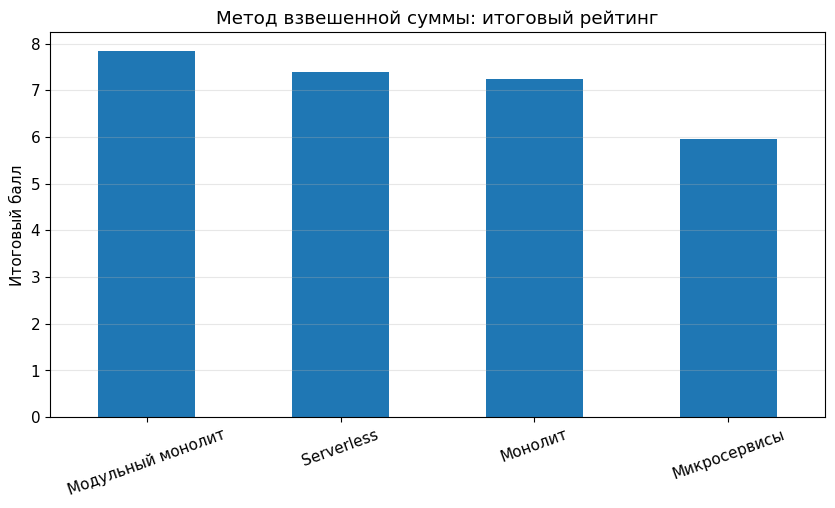

Лучшее решение по методу взвешенной суммы: Модульный монолит


In [ ]:
display(Markdown("## Метод взвешенной суммы"))

weighted_matrix = scores.mul(weights, axis=1)
weighted_result = weighted_matrix.sum(axis=1).sort_values(ascending=False)

display(Markdown("### Взвешенные оценки по критериям"))
display(weighted_matrix.round(3))

display(Markdown("### Итоговый рейтинг альтернатив"))
weighted_result_df = weighted_result.to_frame("Итоговый балл")
weighted_result_df["Место"] = range(1, len(weighted_result_df) + 1)
display(weighted_result_df)

plt.figure()
weighted_result.plot(kind="bar")
plt.title("Метод взвешенной суммы: итоговый рейтинг")
plt.ylabel("Итоговый балл")
plt.xticks(rotation=20)
plt.grid(axis="y", alpha=0.3)
plt.show()

best_weighted = weighted_result.idxmax()
print(f"Лучшее решение по методу взвешенной суммы: {best_weighted}")

## Метод анализа иерархий (МАИ)

### Матрица попарных сравнений критериев

,Масштабируемость,Скорость MVP,Соответствие бюджету,Простота поддержки,Отказоустойчивость,Подход для команды 5 чел.
Масштабируемость,1.000,3.000,4.0,3.000,2.000,5.0
Скорость MVP,0.333,1.000,2.0,2.000,0.500,3.0
Соответствие бюджету,0.250,0.500,1.0,0.500,0.333,2.0
Простота поддержки,0.333,0.500,2.0,1.000,0.500,3.0
Отказоустойчивость,0.500,2.000,3.0,2.000,1.000,4.0
Подход для команды 5 чел.,0.200,0.333,0.5,0.333,0.250,1.0


### Расчёт локальных приоритетов критериев

,Геом. среднее,Локальный приоритет
Масштабируемость,2.66717,0.36324
Скорость MVP,1.12246,0.15287
Соответствие бюджету,0.58880,0.08019
Простота поддержки,0.89090,0.12133
Отказоустойчивость,1.69838,0.23130
Подход для команды 5 чел.,0.37493,0.05106


...

,Масштабируемость,Скорость MVP,Соответствие бюджету,Простота поддержки,Отказоустойчивость,Подход для команды 5 чел.
Монолит,0.05651,0.47234,0.47234,0.35406,0.06897,0.47931
Модульный монолит,0.12096,0.28543,0.28543,0.37438,0.17067,0.29261
Микросервисы,0.52320,0.07252,0.07252,0.07564,0.39943,0.06353
Serverless,0.29933,0.16971,0.16971,0.19592,0.36093,0.16455


### Проверка согласованности

,Критерий,lambda_max,CI,CR
0,Масштабируемость,4.06837,0.02279,0.02532
1,Скорость MVP,4.05108,0.01703,0.01892
2,Соответствие бюджету,4.05108,0.01703,0.01892
3,Простота поддержки,4.01549,0.00516,0.00574
4,Отказоустойчивость,4.03407,0.01136,0.01262
5,Подход для команды 5 чел.,4.03394,0.01131,0.01257


### Глобальные приоритеты альтернатив

,Глобальный приоритет,Место
Микросервисы,0.31176,1
Serverless,0.26394,2
Монолит,0.21400,3
Модульный монолит,0.21030,4


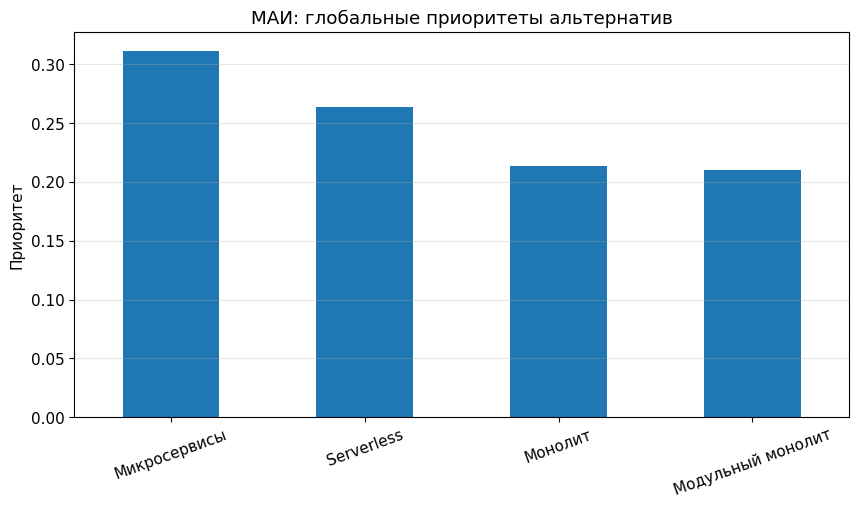

Лучшее решение по методу МАИ: Микросервисы


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

display(Markdown("## Метод анализа иерархий (МАИ)"))

RI = {
    1: 0.00,
    2: 0.00,
    3: 0.58,
    4: 0.90,
    5: 1.12,
    6: 1.24,
    7: 1.32,
    8: 1.41,
    9: 1.45,
    10: 1.49
}

def ahp_geometric_mean_priority(matrix: np.ndarray):
    # Геометрические средние строк:
    # V_i = (a_i1 * a_i2 * ... * a_in)^(1/n)
    row_geom_means = np.prod(matrix, axis=1) ** (1 / matrix.shape[1])

    # Нормировка:
    # w_i = V_i / sum(V_i)
    priorities = row_geom_means / row_geom_means.sum()

    return row_geom_means, priorities

def ahp_consistency(matrix: np.ndarray, priorities: np.ndarray):
    n = matrix.shape[0]
    weighted_sum = matrix @ priorities
    lambda_vec = weighted_sum / priorities
    lambda_max = lambda_vec.mean()

    if n <= 2:
        ci = 0.0
        cr = 0.0
    else:
        ci = (lambda_max - n) / (n - 1)
        cr = ci / RI[n]

    return lambda_max, ci, cr



# 1. Матрица попарных сравнений критериев по Саати

criteria_matrix = np.array([
    [1,   3,   4,   3,   2,   5],
    [1/3, 1,   2,   2,   1/2, 3],
    [1/4, 1/2, 1,   1/2, 1/3, 2],
    [1/3, 1/2, 2,   1,   1/2, 3],
    [1/2, 2,   3,   2,   1,   4],
    [1/5, 1/3, 1/2, 1/3, 1/4, 1]
], dtype=float)

criteria_geom_means, criteria_priority = ahp_geometric_mean_priority(criteria_matrix)
lambda_max_c, ci_c, cr_c = ahp_consistency(criteria_matrix, criteria_priority)

criteria_table = pd.DataFrame({
    "Геом. среднее": criteria_geom_means,
    "Локальный приоритет": criteria_priority
}, index=weights.index)

display(Markdown("### Матрица попарных сравнений критериев"))
display(pd.DataFrame(criteria_matrix, index=weights.index, columns=weights.index).round(3))

display(Markdown("### Расчёт локальных приоритетов критериев"))
display(criteria_table.round(5))

print(f"lambda_max = {lambda_max_c:.5f}")
print(f"CI = {ci_c:.5f}")
print(f"CR = {cr_c:.5f}")



# Матрицы попарных сравнений альтернатив по каждому критерию по Саати
# Порядок альтернатив:
# 1. Монолит
# 2. Модульный монолит
# 3. Микросервисы
# 4. Serverless


scale_matrix = np.array([
    [1,   1/3, 1/7, 1/5],
    [3,   1,   1/5, 1/3],
    [7,   5,   1,   2],
    [5,   3,   1/2, 1]
], dtype=float)

mvp_matrix = np.array([
    [1,   2,   5,   3],
    [1/2, 1,   4,   2],
    [1/5, 1/4, 1,   1/3],
    [1/3, 1/2, 3,   1]
], dtype=float)

budget_matrix = np.array([
    [1,   2,   5,   3],
    [1/2, 1,   4,   2],
    [1/5, 1/4, 1,   1/3],
    [1/3, 1/2, 3,   1]
], dtype=float)

support_matrix = np.array([
    [1,   1,   4,   2],
    [1,   1,   5,   2],
    [1/4, 1/5, 1,   1/3],
    [1/2, 1/2, 3,   1]
], dtype=float)

reliability_matrix = np.array([
    [1,   1/3, 1/5, 1/5],
    [3,   1,   1/3, 1/2],
    [5,   3,   1,   1],
    [5,   2,   1,   1]
], dtype=float)

team_matrix = np.array([
    [1,   2,   6,   3],
    [1/2, 1,   5,   2],
    [1/6, 1/5, 1,   1/3],
    [1/3, 1/2, 3,   1]
], dtype=float)

alternative_matrices = {
    "Масштабируемость": scale_matrix,
    "Скорость MVP": mvp_matrix,
    "Соответствие бюджету": budget_matrix,
    "Простота поддержки": support_matrix,
    "Отказоустойчивость": reliability_matrix,
    "Подход для команды 5 чел.": team_matrix
}



# 3. Расчёт локальных приоритетов альтернатив

local_priorities = {}
geom_means_by_criterion = {}
consistency_table = []

for crit in scores.columns:
    matrix = alternative_matrices[crit]

    row_geom_means, priority = ahp_geometric_mean_priority(matrix)
    lambda_max, ci, cr = ahp_consistency(matrix, priority)

    geom_means_by_criterion[crit] = row_geom_means
    local_priorities[crit] = priority
    consistency_table.append([crit, lambda_max, ci, cr])

    display(Markdown(f"### Критерий: {crit}"))
    display(pd.DataFrame(matrix, index=alternatives, columns=alternatives).round(3))

    temp_table = pd.DataFrame({
        "Геом. среднее": row_geom_means,
        "Локальный приоритет": priority
    }, index=alternatives)

    display(temp_table.round(5))

local_priorities_df = pd.DataFrame(local_priorities, index=alternatives)
consistency_df = pd.DataFrame(consistency_table, columns=["Критерий", "lambda_max", "CI", "CR"])

display(Markdown("### Локальные приоритеты альтернатив по каждому критерию"))
display(local_priorities_df.round(5))

display(Markdown("### Проверка согласованности"))
display(consistency_df.round(5))



# 4. Глобальные приоритеты

criteria_priority_series = pd.Series(criteria_priority, index=weights.index)
global_priority = local_priorities_df.mul(criteria_priority_series, axis=1).sum(axis=1).sort_values(ascending=False)

global_priority_df = global_priority.to_frame("Глобальный приоритет")
global_priority_df["Место"] = range(1, len(global_priority_df) + 1)

display(Markdown("### Глобальные приоритеты альтернатив"))
display(global_priority_df.round(5))

plt.figure()
global_priority.plot(kind="bar")
plt.title("МАИ: глобальные приоритеты альтернатив")
plt.ylabel("Приоритет")
plt.xticks(rotation=20)
plt.grid(axis="y", alpha=0.3)
plt.show()

best_ahp = global_priority.idxmax()
print(f"Лучшее решение по методу МАИ: {best_ahp}")

## Анализ чувствительности

### Результаты по сценариям

,Базовый,Рост и масштабирование,Быстрый и дешевый MVP,Эксплуатационная устойчивость
Монолит,7.25,6.5,8.45,6.95
Модульный монолит,7.85,7.8,7.95,7.75
Микросервисы,5.95,7.1,4.35,5.95
Serverless,7.40,7.8,6.80,7.30


### Места альтернатив по сценариям

,Базовый,Рост и масштабирование,Быстрый и дешевый MVP,Эксплуатационная устойчивость
Монолит,3,4,1,3
Модульный монолит,1,1,2,1
Микросервисы,4,3,4,4
Serverless,2,2,3,2


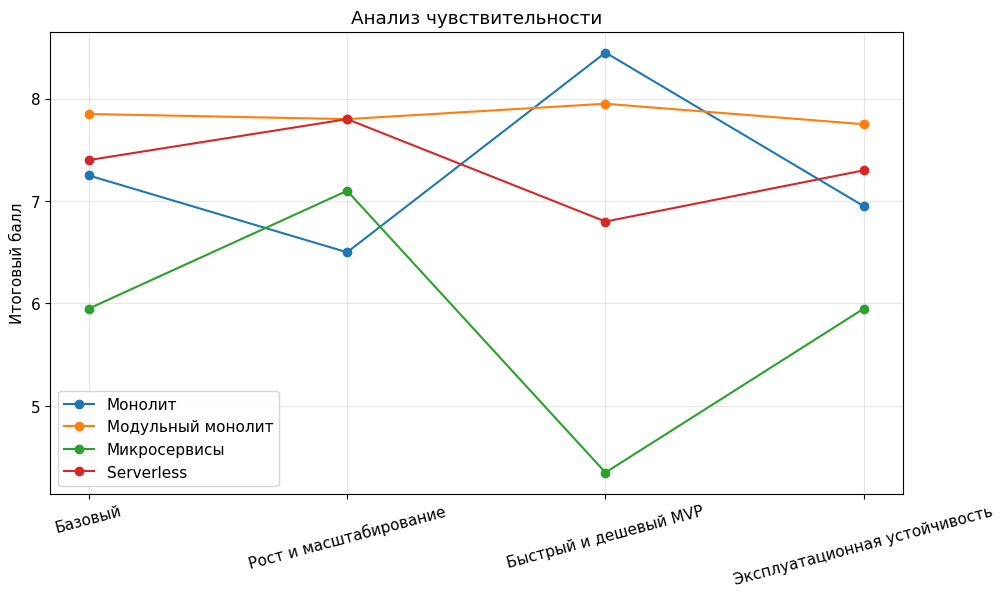

Победитель в сценарии 'Базовый': Модульный монолит
Победитель в сценарии 'Рост и масштабирование': Модульный монолит
Победитель в сценарии 'Быстрый и дешевый MVP': Монолит
Победитель в сценарии 'Эксплуатационная устойчивость': Модульный монолит


In [ ]:
display(Markdown("## Анализ чувствительности"))

scenarios = {
    "Базовый": pd.Series({
        "Масштабируемость": 0.25,
        "Скорость MVP": 0.20,
        "Соответствие бюджету": 0.15,
        "Простота поддержки": 0.15,
        "Отказоустойчивость": 0.15,
        "Подход для команды 5 чел.": 0.10
    }),
    "Рост и масштабирование": pd.Series({
        "Масштабируемость": 0.40,
        "Скорость MVP": 0.10,
        "Соответствие бюджету": 0.10,
        "Простота поддержки": 0.10,
        "Отказоустойчивость": 0.20,
        "Подход для команды 5 чел.": 0.10
    }),
    "Быстрый и дешевый MVP": pd.Series({
        "Масштабируемость": 0.05,
        "Скорость MVP": 0.30,
        "Соответствие бюджету": 0.25,
        "Простота поддержки": 0.15,
        "Отказоустойчивость": 0.05,
        "Подход для команды 5 чел.": 0.20
    }),
    "Эксплуатационная устойчивость": pd.Series({
        "Масштабируемость": 0.20,
        "Скорость MVP": 0.10,
        "Соответствие бюджету": 0.10,
        "Простота поддержки": 0.25,
        "Отказоустойчивость": 0.25,
        "Подход для команды 5 чел.": 0.10
    })
}

scenario_results = {}

for scenario_name, scenario_weights in scenarios.items():
    result = scores.mul(scenario_weights, axis=1).sum(axis=1)
    scenario_results[scenario_name] = result

scenario_df = pd.DataFrame(scenario_results)
display(Markdown("### Результаты по сценариям"))
display(scenario_df.round(3))

scenario_ranks = scenario_df.rank(ascending=False, method="min")
display(Markdown("### Места альтернатив по сценариям"))
display(scenario_ranks.astype(int))

plt.figure(figsize=(11, 6))
for alt in alternatives:
    plt.plot(scenario_df.columns, scenario_df.loc[alt], marker="o", label=alt)

plt.title("Анализ чувствительности")
plt.ylabel("Итоговый балл")
plt.xticks(rotation=15)
plt.grid(alpha=0.3)
plt.legend()
plt.show()

for scenario_name in scenario_df.columns:
    winner = scenario_df[scenario_name].idxmax()
    print(f"Победитель в сценарии '{scenario_name}': {winner}")

In [ ]:
final_table = scores.copy()
final_table.loc["Вес критерия"] = weights

display(Markdown("## Итоговая таблица"))
display(final_table)

## Итоговая таблица

,Масштабируемость,Скорость MVP,Соответствие бюджету,Простота поддержки,Отказоустойчивость,Подход для команды 5 чел.
Монолит,5.00,9.0,9.00,8.00,5.00,9.0
Модульный монолит,8.00,8.0,8.00,8.00,7.00,8.0
Микросервисы,10.00,4.0,4.00,3.00,8.00,4.0
Serverless,9.00,7.0,7.00,6.00,8.00,6.0
Вес критерия,0.25,0.2,0.15,0.15,0.15,0.1
